# Projektarbete: Undersökning av samband av arbetslöshet och mental ohälsa i Sverige efter region och kön

I detta projekt undersöks sambandet mellan arbetslöshet, mental hälsa och befolkningsstruktur i Sveriges län över perioden 2008–2024. Studien använder data från SCB om arbetslöshet och medelfolkmängd och registerdata från Socialstyrelsen över patienter med psykiatriska diagnoser (F00–F99). Genom att kombinera dessa dataset skapas en heltäckande databas som möjliggör en analys av regionala skillnader och trender.

Arbetet inleds med hämtning av rådata via SCB:s API i PX-format som sedan omvandlas till CSV för vidare bearbetning. Därefter görs datarensning och aggregering, bland annat genom att kvartalsdata om arbetslöshet omvandlas till årsvärden och medelfolkmängddata kombineras för att beräkna andel arbetslösa i procent - per län, kön och år. Ytterligare en datakälla från Socialstyrelsen om psykiatrisk diagnostik läggs till nedladdad som CSV-fil, vilken struktureras om från bred till långformat för att underlätta analys. Även där beräknas andelen patienter i procent med hjälp av medelfolkmängddata. 

En central utmaning i projektet är datakvaliteten och tillgängligheten. Ursprungligen avsåg studien att genomföra en analys med fokus på regionala skillnader, men SCB:s dataset saknade möjlighet att kombinera regional indelning med specifika åldersklasser. Detta medför att åldersintervall som 15–19 år och 65–74 år inkluderas i analysen, vilket kan påverka resultatens tillförlitlighet då dessa grupper innehåller många studerande respektive pensionärer. En bättre variabelval hade därför kunnat innebära åldersspecifika klasser istället för en ren regional indelning.

Studien diskuterar vikten av variabelval och metodologiska överväganden samt identifierar och hanterar luckor i befintliga dataset. Resultatet presenteras i en sammanslagen tabell som används för analys och visualisering. 

Projektet presenterar en tydlig och strukturerad metod för att sammanföra och analysera offentliga dataset. Studien ger också konkreta insikter om hur arbetslöshet och psykisk hälsa varierar mellan några av Sveriges län över tid. Det är viktigt att följa arbetsflödet steg för steg i Jupyter-anteckningsboken – och köra alla celler i rätt ordning från början till slut. Detta säkerställer reproducerbarhet då tabellooperationordningen är viktigt. 

### API- anrop från SCB

Vi börjar med att importera nödvändiga bibliotek för att arbeta med API-anrop. URL och Anrop instruktioner finns på SCB:s hemsida och används för att göra förfrågan. Varje API-svar sparas i dess px-format till lokal disk, vilket säkerställer reproducerbarhet och möjliggör vidare analys utan att behöva göra upprepade nätverksanrop. Koden följer etik och etikett. Det används lämpligt User-Agent samt time.sleep för att inte överbelasta servern. Sedan konverteras px-filerna till CSV- filer för vidare bearbetning.


In [34]:
import requests
import time
from pathlib import Path
from pyaxis import pyaxis
import pandas as pd


URL = "https://api.scb.se/OV0104/v1/doris/sv/ssd/START/AM/AM0401/AM0401N/NAKUBefolkningLK"

DATA_DIR = Path("data_scb")
FILE_PATH = DATA_DIR / "Arblosa_Region_2008_2024.px"

HEADERS = {
    "Content-Type": "application/json",
    "User-Agent": "Studentproject/Databehandling"
}
PAYLOAD = {"query":[{"code":"Region","selection":{"filter":"vs:RegionLän99EjAggr","values":["01","03","04","05","06","07","08","09","10","12","13","14","17","18","19","20","21","22","23","24","25"]}},{"code":"Arbetskraftstillh","selection":{"filter":"item","values":["ALÖS"]}},{"code":"Kon","selection":{"filter":"item","values":["1","2","1+2"]}},{"code":"ContentsCode","selection":{"filter":"item","values":["AM0401UZ"]}},{"code":"Tid","selection":{"filter":"item","values":["2008K1","2008K2","2008K3","2008K4","2009K1","2009K2","2009K3","2009K4","2010K1","2010K2","2010K3","2010K4","2011K1","2011K2","2011K3","2011K4","2012K1","2012K2","2012K3","2012K4","2013K1","2013K2","2013K3","2013K4","2014K1","2014K2","2014K3","2014K4","2015K1","2015K2","2015K3","2015K4","2016K1","2016K2","2016K3","2016K4","2017K1","2017K2","2017K3","2017K4","2018K1","2018K2","2018K3","2018K4","2019K1","2019K2","2019K3","2019K4","2020K1","2020K2","2020K3","2020K4","2021K1","2021K2","2021K3","2021K4","2022K1","2022K2","2022K3","2022K4","2023K1","2023K2","2023K3","2023K4","2024K1","2024K2","2024K3","2024K4"]}}],"response":{"format":"px"}}

# Skapa data-mappen om den inte finns
DATA_DIR.mkdir(exist_ok=True)

# Ladda inte ner igen om filen redan finns
if FILE_PATH.exists():
    print(f"Filen finns redan: {FILE_PATH}")
else:
    # Etisk paus före anrop
    time.sleep(2)

    response = requests.post(
        URL,
        json=PAYLOAD,
        headers=HEADERS,
        timeout=60
    )

    if response.status_code == 200:
        FILE_PATH.write_bytes(response.content)
        print(f"Data hämtad och sparad som: {FILE_PATH}")
    else:
        raise RuntimeError(
            f"SCB-anrop misslyckades "
            f"(status {response.status_code}): {response.text}"
        )
        

px_file = Path("data_scb/Arblosa_Region_2008_2024.px")
csv_file  = Path("data_scb/Arblosa_Region_2008_2024.csv")

# läs PX 
px = pyaxis.parse(str(px_file), encoding="latin-1")

df = px["DATA"]

# Säkerställ numeriska värden
if "value" in df.columns:
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Spara som CSV (UTF-8 för vidare analys)
df.to_csv(
    csv_file,
    index=False,
    encoding="utf-8"  
)

print(f"CSV skapad: {csv_file}")




URL = "https://api.scb.se/OV0104/v1/doris/sv/ssd/START/BE/BE0101/BE0101D/MedelfolkFodelsear"

DATA_DIR = Path("data_scb")
PX_FILE = DATA_DIR / "Medelfolkmangd_2008_2024.px"

HEADERS = {
    "Content-Type": "application/json",
    "User-Agent": "Studentproject/Databehandling"
}

PAYLOAD = {"query":[{"code":"Region","selection":{"filter":"vs:RegionLän07","values":["01","03","04","05","06","07","08","09","10","12","13","14","17","18","19","20","21","22","23","24","25"]}},{"code":"Alder","selection":{"filter":"agg:Ålder5år","values":["15-19","20-24","25-29","30-34","35-39","40-44","45-49","50-54","55-59","60-64","65-69","70-74"]}},{"code":"Kon","selection":{"filter":"item","values":["1","2"]}},{"code":"Tid","selection":{"filter":"item","values":[str(year) for year in range(2008,2025)]}}],"response":{"format":"px"}}

# Ladda inte ner igen om filen redan finns
if PX_FILE.exists():
    print(f"Filen finns redan: {PX_FILE}")
else:
    # Etisk paus före anrop
    time.sleep(2)

    response = requests.post(URL, json=PAYLOAD, headers=HEADERS, timeout=60)

    if response.status_code == 200:
        PX_FILE.write_bytes(response.content)
        print(f"Data hämtad och sparad som: {PX_FILE}")
    else:
        raise RuntimeError(
            f"SCB-anrop misslyckades (status {response.status_code}): {response.text}"
        )


# Filer
px_file = Path("data_scb/Medelfolkmangd_2008_2024.px")
csv_file = Path("data_scb/Medelfolkmangd_2008_2024.csv")


px = pyaxis.parse(str(px_file), encoding="latin-1")

df = px["DATA"]

# Säkerställ numeriska värden
if "value" in df.columns:
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    
# Spara som CSV (UTF-8 för vidare analys)
df.to_csv(csv_file, index=False, encoding="utf-8")

print(f"CSV skapad: {csv_file}")


Filen finns redan: data_scb/Arblosa_Region_2008_2024.px
CSV skapad: data_scb/Arblosa_Region_2008_2024.csv
Filen finns redan: data_scb/Medelfolkmangd_2008_2024.px
CSV skapad: data_scb/Medelfolkmangd_2008_2024.csv


### Omvandling till DATAFRAME

Vi läser CSV filerna som DATAFRAME för att börja göra detabehandlingen. Vi undersöker saknade värden och ser till att ersätt dem med 0 för vidare beräkningar. Då vi vill skapa kolumner andel patienter och andel arbetslösa kommer vi att droppa saknade värdena - om sådana skulle finnas - just för datasetet medelfolkmäng. Detta för att undvika division med 0. Men i övrigt kommer vi att ersätta saknade värden med 0 för att vid melt och merge inte stötta på större problem. 

In [35]:
region_csv = Path("data_scb/Arblosa_Region_2008_2024.csv")
medelfokmangd_csv = Path("data_scb/Medelfolkmangd_2008_2024.csv")

df_region = pd.read_csv(region_csv, encoding="utf-8")
df_medelfokmangd = pd.read_csv(medelfokmangd_csv, encoding="utf-8")

### Behandling av medelfolkmängd datasetet
Vi har alltså inga skanade värden eller 0 värden i datasetet för folkmängd. Men datasetet är organiserat bl.a. efter åldergrupper. Då vi saknade åldersdata för arbetslöshet vi slår samman alla åldergrupper. Vi har åldrarna mellan 15-74 för alla dataset. Vi skapar dessutom medelfolkmängdinformation för båda könen som vi döper till 'totalt'. Dessutom lägger vi till medelfolkmängd för hela riket. Vi kommer använda det för att analysera arbetslöshet och psykisk ohälsa oberoende av kön samt över hela riket. 

In [36]:
print("DataFrame: Medelfokmängd efter Län")
df_medelfokmangd

DataFrame: Medelfokmängd efter Län


,region,ålder,kön,tabellinnehåll,år,DATA
0,Stockholms län,15-19 år,män,Antal,2008,64525.0
1,Stockholms län,15-19 år,män,Antal,2009,65405.0
2,Stockholms län,15-19 år,män,Antal,2010,64692.5
3,Stockholms län,15-19 år,män,Antal,2011,63171.0
4,Stockholms län,15-19 år,män,Antal,2012,61239.5
...,...,...,...,...,...,...
8563,Norrbottens län,70-74 år,kvinnor,Antal,2020,8156.0
8564,Norrbottens län,70-74 år,kvinnor,Antal,2021,7932.5
8565,Norrbottens län,70-74 år,kvinnor,Antal,2022,7724.5
8566,Norrbottens län,70-74 år,kvinnor,Antal,2023,7517.0


In [37]:
df_medelfokmangd.isna().sum()

region            0
ålder             0
kön               0
tabellinnehåll    0
år                0
DATA              0
dtype: int64

In [38]:
(df_medelfokmangd==0).sum()

region            0
ålder             0
kön               0
tabellinnehåll    0
år                0
DATA              0
dtype: int64

In [39]:
df_medelfokmangd["kön"].unique()

array(['män', 'kvinnor'], dtype=object)

In [40]:
df_medelfokmangd["region"].unique()

array(['Stockholms län', 'Uppsala län', 'Södermanlands län',
       'Östergötlands län', 'Jönköpings län', 'Kronobergs län',
       'Kalmar län', 'Gotlands län', 'Blekinge län', 'Skåne län',
       'Hallands län', 'Västra Götalands län', 'Värmlands län',
       'Örebro län', 'Västmanlands län', 'Dalarnas län', 'Gävleborgs län',
       'Västernorrlands län', 'Jämtlands län', 'Västerbottens län',
       'Norrbottens län'], dtype=object)

In [41]:
import numpy as np

df_medelfokmangd_grouped = df_medelfokmangd.copy()

# Gruppera och summera DATA per region, kön och år
df_medelfokmangd_grouped = (
    df_medelfokmangd_grouped
    .groupby(["region", "kön", "år"], as_index=False)
    .agg({"DATA": "sum"})
)
df_medelfokmangd_grouped = df_medelfokmangd_grouped.rename(columns={"DATA": "medelfolkmängd"})

# Lägg till totalsummor per region och år (kön = "totalt")
df_totalt = (
    df_medelfokmangd_grouped[df_medelfokmangd_grouped["kön"].isin(["män", "kvinnor"])]
    .groupby(["region", "år"], as_index=False)
    .agg({"medelfolkmängd": "sum"})
)

df_totalt["kön"] = "totalt"

# Lägg till i df_medelfokmangd_grouped
df_medelfokmangd_grouped = pd.concat([df_medelfokmangd_grouped, df_totalt], ignore_index=True)

df_medelfokmangd_grouped

,region,kön,år,medelfolkmängd
0,Blekinge län,kvinnor,2008,54692.0
1,Blekinge län,kvinnor,2009,54861.5
2,Blekinge län,kvinnor,2010,54987.5
3,Blekinge län,kvinnor,2011,54914.5
4,Blekinge län,kvinnor,2012,54588.5
...,...,...,...,...
1066,Östergötlands län,totalt,2020,339371.0
1067,Östergötlands län,totalt,2021,339642.5
1068,Östergötlands län,totalt,2022,340597.0
1069,Östergötlands län,totalt,2023,341245.0


In [42]:
df_medelfokmangd_riket = (
    df_medelfokmangd_grouped
    .groupby(["kön", "år"], as_index=False)
    .agg({"medelfolkmängd": "sum"})
)

# Lägg till region
df_medelfokmangd_riket["region"] = "Riket"

# Samma kolumnordning
df_medelfokmangd_riket = df_medelfokmangd_riket[
    ["region", "kön", "år", "medelfolkmängd"]
]

df_medelfokmangd_grouped_full = pd.concat(
    [df_medelfokmangd_grouped, df_medelfokmangd_riket],
    ignore_index=True
)
df_medelfokmangd_grouped_full

,region,kön,år,medelfolkmängd
0,Blekinge län,kvinnor,2008,54692.0
1,Blekinge län,kvinnor,2009,54861.5
2,Blekinge län,kvinnor,2010,54987.5
3,Blekinge län,kvinnor,2011,54914.5
4,Blekinge län,kvinnor,2012,54588.5
...,...,...,...,...
1117,Riket,totalt,2020,7538226.0
1118,Riket,totalt,2021,7561613.0
1119,Riket,totalt,2022,7598661.0
1120,Riket,totalt,2023,7630642.0


### Behandling av Region-arbetslöshet datasetet

Vi har 946 saknade värden i denna dataset. Det saknas alltså information om arbetslöshet för 946 kvartaler. Vi ersätter alla dessa värden med 0 för vidare beräkningar. Vi behöver inte se vilka län som har saknade värden för respektive kvartal. Om det till exempel saknas information om arbetslöshet för 2008k1,k2 men finns information för 2008k3,k4 kan detta användas för beräkningar. Det är lite mindre tillförlitlig information men fungerar och ger en ungefärlig bild av vad arbetslösheten ungefär är för respektive år som har saknade kvartalvärden. Vi kommer summera arbetslöshetsvärdena för alla fyra kvartaler för att få information för respektive år. 
Då Gottlands län och Norrbottens län har flest saknade värden per kvartal för 'båda könen'- 36 respektive 14 - kommer vi att vara mer kritiska vid vidareanalys för dessa län. I senare analys kommer regionala analyser utföras oberoende av köneskillnader. Analys av skillnader mellan könen kommer göras endast på riksnivå, därmed behöver vi inte undersöka saknade värden för respektive könen. Däremot kommer vi att skaffa information om antal arbetslösa på riksnivå genom summering för vidare analyser.

In [43]:
print("DataFrame: Arbetslöshet efter Län ")
df_region

DataFrame: Arbetslöshet efter Län 


,region,arbetskraftstillhörighet,kön,tabellinnehåll,kvartal,DATA
0,Stockholms län,arbetslösa,män,1000-tal,2008K1,28.6
1,Stockholms län,arbetslösa,män,1000-tal,2008K2,30.7
2,Stockholms län,arbetslösa,män,1000-tal,2008K3,28.2
3,Stockholms län,arbetslösa,män,1000-tal,2008K4,28.3
4,Stockholms län,arbetslösa,män,1000-tal,2009K1,35.6
...,...,...,...,...,...,...
4279,Norrbottens län,arbetslösa,totalt,1000-tal,2023K4,NaN
4280,Norrbottens län,arbetslösa,totalt,1000-tal,2024K1,NaN
4281,Norrbottens län,arbetslösa,totalt,1000-tal,2024K2,NaN
4282,Norrbottens län,arbetslösa,totalt,1000-tal,2024K3,NaN


In [44]:
df_region["region"].unique()

array(['Stockholms län', 'Uppsala län', 'Södermanlands län',
       'Östergötlands län', 'Jönköpings län', 'Kronobergs län',
       'Kalmar län', 'Gotlands län', 'Blekinge län', 'Skåne län',
       'Hallands län', 'Västra Götalands län', 'Värmlands län',
       'Örebro län', 'Västmanlands län', 'Dalarnas län', 'Gävleborgs län',
       'Västernorrlands län', 'Jämtlands län', 'Västerbottens län',
       'Norrbottens län'], dtype=object)

In [45]:
df_region.isna().sum()

region                        0
arbetskraftstillhörighet      0
kön                           0
tabellinnehåll                0
kvartal                       0
DATA                        946
dtype: int64

In [46]:
(df_region==0).sum()

region                      0
arbetskraftstillhörighet    0
kön                         0
tabellinnehåll              0
kvartal                     0
DATA                        0
dtype: int64

In [47]:
# Ersätt NaN med 0 i kolumnen DATA för beräkningar 
df_region["DATA"] = df_region["DATA"].fillna(0)

In [48]:
# Filtrera på totalt kön
df_totalt = df_region[df_region["kön"] == "totalt"]

# Filtrera rader där DATA är 0
df_zeros = df_totalt[df_totalt["DATA"] == 0]

# Visa vilka län som har minst en rad med 0
print("Län med minst en noll i 'DATA' (totalt):")
print(df_zeros["region"].unique())

# Räkna antal rader med 0 per län
zeros_per_lan = df_zeros.groupby("region").size().reset_index(name="antal_rader_med_0")
print("\nAntal rader med 0 per län (totalt):")
print(zeros_per_lan)


Län med minst en noll i 'DATA' (totalt):
['Kronobergs län' 'Kalmar län' 'Gotlands län' 'Blekinge län'
 'Hallands län' 'Värmlands län' 'Örebro län' 'Dalarnas län'
 'Gävleborgs län' 'Västernorrlands län' 'Jämtlands län'
 'Västerbottens län' 'Norrbottens län']

Antal rader med 0 per län (totalt):
                 region  antal_rader_med_0
0          Blekinge län                  2
1          Dalarnas län                  4
2          Gotlands län                 36
3        Gävleborgs län                  2
4          Hallands län                  3
5         Jämtlands län                  5
6            Kalmar län                  6
7        Kronobergs län                  5
8       Norrbottens län                 14
9         Värmlands län                  4
10    Västerbottens län                  2
11  Västernorrlands län                  6
12           Örebro län                  1


In [49]:
df_region_year = df_region.copy()

# Skapar kolumn för år
df_region_year["år"] = df_region_year["kvartal"].str[:4]

# Omvandlar DATA till faktiska antal
df_region_year["DATA"] = df_region_year["DATA"] * 1000

# Grupperar på region, arbetskraftstillhörighet, kön och år och summerar DATA
df_region_grouped = (
    df_region_year
    .groupby(["region", "kön", "år"], as_index=False)
    .agg({"DATA": "sum"})
)
df_region_grouped = df_region_grouped.rename(columns={"DATA": "antal arbetslösa"})
df_region_grouped

,region,kön,år,antal arbetslösa
0,Blekinge län,kvinnor,2008,10000.0
1,Blekinge län,kvinnor,2009,12300.0
2,Blekinge län,kvinnor,2010,13100.0
3,Blekinge län,kvinnor,2011,12700.0
4,Blekinge län,kvinnor,2012,11900.0
...,...,...,...,...
1066,Östergötlands län,totalt,2020,82200.0
1067,Östergötlands län,totalt,2021,91000.0
1068,Östergötlands län,totalt,2022,86200.0
1069,Östergötlands län,totalt,2023,96500.0


In [50]:
# Skapa Riket från alla län
df_riket = (
    df_region_grouped
    .groupby(["kön", "år"], as_index=False)
    .agg({"antal arbetslösa": "sum"})
)

# Lägg till region = "Riket"
df_riket["region"] = "Riket"

# Ordna kolumnerna samma som df_region_grouped
df_riket = df_riket[["region", "kön", "år", "antal arbetslösa"]]

df_region_grouped_full = pd.concat(
    [df_region_grouped, df_riket],
    ignore_index=True
)
df_region_grouped_full

,region,kön,år,antal arbetslösa
0,Blekinge län,kvinnor,2008,10000.0
1,Blekinge län,kvinnor,2009,12300.0
2,Blekinge län,kvinnor,2010,13100.0
3,Blekinge län,kvinnor,2011,12700.0
4,Blekinge län,kvinnor,2012,11900.0
...,...,...,...,...
1117,Riket,totalt,2020,1858200.0
1118,Riket,totalt,2021,1915700.0
1119,Riket,totalt,2022,1573000.0
1120,Riket,totalt,2023,1679600.0


### Ihopslagning av dataseten 
I denna kodbit kommer vi att slå ihop föregående två dataset och skapa ny kolumn, andel arbetslösa. genom att dela antalet arbetslösa för respektive kön, reion och år på medelfolkmängd. Vi har redan behandlat saknade värden tidigare samt 0 värden i medelfolkmängd, så divion med 0 förekommer inte.

In [51]:
df_region_grouped_full["år"] = df_region_grouped_full["år"].astype(int)
df_medelfokmangd_grouped_full["år"] = df_medelfokmangd_grouped_full["år"].astype(int)


#Slår ihop 
df_merged = df_region_grouped_full.merge(
    df_medelfokmangd_grouped_full,
    on=["region", "kön", "år"],
    how="left"
)

#Beräknar andel arbetslösa procent 
df_merged["andel arbetslösa (%)"] = ((df_merged["antal arbetslösa"] / df_merged["medelfolkmängd"]) * 100).round(1)

df_merged


,region,kön,år,antal arbetslösa,medelfolkmängd,andel arbetslösa (%)
0,Blekinge län,kvinnor,2008,10000.0,54692.0,18.3
1,Blekinge län,kvinnor,2009,12300.0,54861.5,22.4
2,Blekinge län,kvinnor,2010,13100.0,54987.5,23.8
3,Blekinge län,kvinnor,2011,12700.0,54914.5,23.1
4,Blekinge län,kvinnor,2012,11900.0,54588.5,21.8
...,...,...,...,...,...,...
1117,Riket,totalt,2020,1858200.0,7538226.0,24.7
1118,Riket,totalt,2021,1915700.0,7561613.0,25.3
1119,Riket,totalt,2022,1573000.0,7598661.0,20.7
1120,Riket,totalt,2023,1679600.0,7630642.0,22.0


In [52]:
df_merged.isna().sum()

region                  0
kön                     0
år                      0
antal arbetslösa        0
medelfolkmängd          0
andel arbetslösa (%)    0
dtype: int64

### Inläsning av CSV filen från Socialstyrelsen över patienter med psykiatriska diagnoser (F00–F99)
Vi gör datan i lång format för att kunna slå samman med vår tidigare tabell df_merged. 
I denna dataset finner vi saknade värden, men dessa är extra rader med information. Vi väljer att droppa dessa samt rader med 'Hemlän saknas' då det omfattar endast ca 1000 patienter och inte påverkar analysen mycket. Datasetet har inga rader med 0 behöver tas med försiktighet.

In [53]:
socialstyrelse_csv = Path("data_socialstyrelsen/Statistikdatabasen_region_15-74.csv")

df_socialstyrelse = pd.read_csv(
    socialstyrelse_csv,
    sep=";",        # semikolon
    encoding="utf-8",
    skiprows=1      # hoppa första raden (metadata)
)

df_socialstyrelse

,Hemortslän,Kön,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Riket,Män,104047.0,107032.0,112364.0,120489.0,127698.0,135401.0,143232.0,148368.0,151981.0,155584.0,158424.0,161380.0,160468.0,166071.0,169597.0,177151.0,179762.0
1,Riket,Kvinnor,119842.0,121190.0,126026.0,135186.0,142097.0,151978.0,160676.0,166628.0,172494.0,179640.0,182768.0,186106.0,185748.0,195923.0,204128.0,213904.0,218185.0
2,Riket,Båda könen,223889.0,228222.0,238390.0,255675.0,269795.0,287379.0,303908.0,314996.0,324475.0,335224.0,341192.0,347486.0,346216.0,361994.0,373725.0,391055.0,397947.0
3,Stockholms län,Män,25311.0,25515.0,29044.0,32436.0,36977.0,39962.0,42591.0,43520.0,44437.0,45633.0,46694.0,47470.0,47227.0,48788.0,49578.0,52041.0,53123.0
4,Stockholms län,Kvinnor,29412.0,28391.0,33119.0,37558.0,42773.0,47320.0,50768.0,51959.0,54242.0,56629.0,57376.0,57385.0,56851.0,59767.0,61598.0,63979.0,65138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Hemlän saknas,Män,116.0,172.0,168.0,92.0,120.0,90.0,132.0,801.0,397.0,474.0,438.0,344.0,297.0,310.0,290.0,336.0,376.0
67,Hemlän saknas,Kvinnor,68.0,119.0,91.0,43.0,47.0,51.0,69.0,808.0,205.0,306.0,291.0,260.0,255.0,273.0,232.0,275.0,297.0
68,Hemlän saknas,Båda könen,184.0,291.0,259.0,135.0,167.0,141.0,201.0,1609.0,602.0,780.0,729.0,604.0,552.0,583.0,522.0,611.0,673.0
69,Statistik presenteras från 2008 eftersom kvali...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
year_cols_df_socialstyrelse = [col for col in df_socialstyrelse.columns if col.isdigit()]

df_socialstyrelse_long = df_socialstyrelse.melt(
    id_vars=['Hemortslän','Kön'], # oförändad
    value_vars=year_cols_df_socialstyrelse, #kolumnerna som blir rader
    var_name='år', # nykolumnnamn för år
    value_name='antal patienter' # ny kolumnnamn för antal patienter
)

df_socialstyrelse_long['år'] = df_socialstyrelse_long['år'].astype(int) #omvandlar till numeriska
df_socialstyrelse_long['antal patienter'] = df_socialstyrelse_long['antal patienter'].astype(float) # omvandlar till heltal 

df_socialstyrelse_long = df_socialstyrelse_long.rename(columns={"Hemortslän": "region"})
df_socialstyrelse_long = df_socialstyrelse_long.rename(columns={"Kön": "kön"})
df_socialstyrelse_long["kön"] = df_socialstyrelse_long["kön"].replace({"Båda könen": "totalt"})
df_socialstyrelse_long["kön"] = df_socialstyrelse_long["kön"].replace({"Män": "män"})
df_socialstyrelse_long["kön"] = df_socialstyrelse_long["kön"].replace({"Kvinnor": "kvinnor"})

print('\nTabell: Antal patienter med diagnoskod:F00-F99')
df_socialstyrelse_long


Tabell: Antal patienter med diagnoskod:F00-F99


,region,kön,år,antal patienter
0,Riket,män,2008,104047.0
1,Riket,kvinnor,2008,119842.0
2,Riket,totalt,2008,223889.0
3,Stockholms län,män,2008,25311.0
4,Stockholms län,kvinnor,2008,29412.0
...,...,...,...,...
1202,Hemlän saknas,män,2024,376.0
1203,Hemlän saknas,kvinnor,2024,297.0
1204,Hemlän saknas,totalt,2024,673.0
1205,Statistik presenteras från 2008 eftersom kvali...,NaN,2024,NaN


In [55]:
df_socialstyrelse_long.isna().sum() # kontroll

region              0
kön                34
år                  0
antal patienter    34
dtype: int64

In [56]:
df_socialstyrelse_long[
    df_socialstyrelse_long["kön"].isna() &
    df_socialstyrelse_long["antal patienter"].isna()] 

,region,kön,år,antal patienter
69,Statistik presenteras från 2008 eftersom kvali...,NaN,2008,NaN
70,Socialstyrelsens statistikdatabas 2026-01-07,NaN,2008,NaN
140,Statistik presenteras från 2008 eftersom kvali...,NaN,2009,NaN
141,Socialstyrelsens statistikdatabas 2026-01-07,NaN,2009,NaN
211,Statistik presenteras från 2008 eftersom kvali...,NaN,2010,NaN
212,Socialstyrelsens statistikdatabas 2026-01-07,NaN,2010,NaN
282,Statistik presenteras från 2008 eftersom kvali...,NaN,2011,NaN
283,Socialstyrelsens statistikdatabas 2026-01-07,NaN,2011,NaN
353,Statistik presenteras från 2008 eftersom kvali...,NaN,2012,NaN
354,Socialstyrelsens statistikdatabas 2026-01-07,NaN,2012,NaN


In [57]:
df_socialstyrelse_long_clean = df_socialstyrelse_long.dropna().copy() # Vi förlorar ingen viktig data 
df_socialstyrelse_long_clean

,region,kön,år,antal patienter
0,Riket,män,2008,104047.0
1,Riket,kvinnor,2008,119842.0
2,Riket,totalt,2008,223889.0
3,Stockholms län,män,2008,25311.0
4,Stockholms län,kvinnor,2008,29412.0
...,...,...,...,...
1200,Norrbottens län,kvinnor,2024,4731.0
1201,Norrbottens län,totalt,2024,8584.0
1202,Hemlän saknas,män,2024,376.0
1203,Hemlän saknas,kvinnor,2024,297.0


In [58]:
(df_socialstyrelse_long_clean==0).sum()

region             0
kön                0
år                 0
antal patienter    0
dtype: int64

In [59]:
# 3 rader data med totalt 1346 patienter droppas så jämförelse mellan län kan utföras.Tas bort först nu för att inte skulle påverka Riket summan 
df_socialstyrelse_long_clean = df_socialstyrelse_long_clean[df_socialstyrelse_long_clean['region'] != "Hemlän saknas"]
df_socialstyrelse_long_clean

,region,kön,år,antal patienter
0,Riket,män,2008,104047.0
1,Riket,kvinnor,2008,119842.0
2,Riket,totalt,2008,223889.0
3,Stockholms län,män,2008,25311.0
4,Stockholms län,kvinnor,2008,29412.0
...,...,...,...,...
1197,Västerbottens län,kvinnor,2024,6440.0
1198,Västerbottens län,totalt,2024,11279.0
1199,Norrbottens län,män,2024,3853.0
1200,Norrbottens län,kvinnor,2024,4731.0


### Ihopslagning av socialstyrelsens dataset till de andra  
I denna kodbit kommer vi merge:a ytterligare och även beräkna andelen patienter genom att dela antalet patienter med antalet medelfolkmängd. Vi får nu en tabell som vi kan använda för att visualisera data och analysera om tendens på samband mellan arbetslöshet och psykisk ohälsa dyker upp. 

In [60]:
merge_df = df_merged.merge(
    df_socialstyrelse_long_clean,
    on=['region', 'kön', 'år'],
    how='left'  
)

merge_df

,region,kön,år,antal arbetslösa,medelfolkmängd,andel arbetslösa (%),antal patienter
0,Blekinge län,kvinnor,2008,10000.0,54692.0,18.3,2045.0
1,Blekinge län,kvinnor,2009,12300.0,54861.5,22.4,2229.0
2,Blekinge län,kvinnor,2010,13100.0,54987.5,23.8,743.0
3,Blekinge län,kvinnor,2011,12700.0,54914.5,23.1,2369.0
4,Blekinge län,kvinnor,2012,11900.0,54588.5,21.8,2193.0
...,...,...,...,...,...,...,...
1117,Riket,totalt,2020,1858200.0,7538226.0,24.7,346216.0
1118,Riket,totalt,2021,1915700.0,7561613.0,25.3,361994.0
1119,Riket,totalt,2022,1573000.0,7598661.0,20.7,373725.0
1120,Riket,totalt,2023,1679600.0,7630642.0,22.0,391055.0


In [61]:
merge_df.isna().sum()

region                  0
kön                     0
år                      0
antal arbetslösa        0
medelfolkmängd          0
andel arbetslösa (%)    0
antal patienter         0
dtype: int64

In [62]:
merge_df["andel patienter(%)"] = ((
    merge_df["antal patienter"] / merge_df["medelfolkmängd"]
) * 100).round(1)
merge_df[[
    "region", "kön", "år",
    "antal patienter", "medelfolkmängd",
    "andel patienter(%)"
]]

print('\n\n               Tabell av regional arbetslöshet och mental ohälsa i Sverige')
merge_df



               Tabell av regional arbetslöshet och mental ohälsa i Sverige


,region,kön,år,antal arbetslösa,medelfolkmängd,andel arbetslösa (%),antal patienter,andel patienter(%)
0,Blekinge län,kvinnor,2008,10000.0,54692.0,18.3,2045.0,3.7
1,Blekinge län,kvinnor,2009,12300.0,54861.5,22.4,2229.0,4.1
2,Blekinge län,kvinnor,2010,13100.0,54987.5,23.8,743.0,1.4
3,Blekinge län,kvinnor,2011,12700.0,54914.5,23.1,2369.0,4.3
4,Blekinge län,kvinnor,2012,11900.0,54588.5,21.8,2193.0,4.0
...,...,...,...,...,...,...,...,...
1117,Riket,totalt,2020,1858200.0,7538226.0,24.7,346216.0,4.6
1118,Riket,totalt,2021,1915700.0,7561613.0,25.3,361994.0,4.8
1119,Riket,totalt,2022,1573000.0,7598661.0,20.7,373725.0,4.9
1120,Riket,totalt,2023,1679600.0,7630642.0,22.0,391055.0,5.1


## Visualisering och grafanlys

### Figur 1 

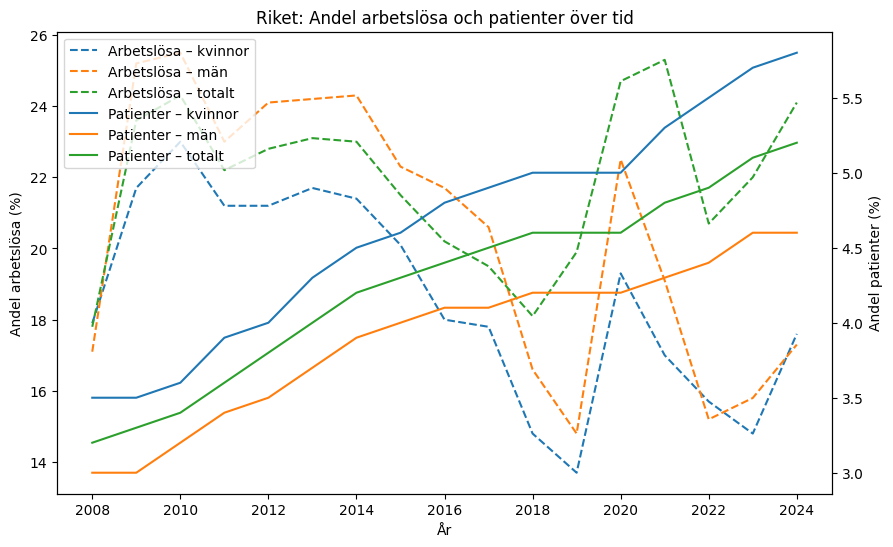

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Filtrera Riket
riket_df = merge_df[merge_df["region"] == "Riket"]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Första y-axeln: andel arbetslösa
for kon in ["kvinnor", "män", "totalt"]:
    subset = riket_df[riket_df["kön"] == kon]
    ax1.plot(
        subset["år"],
        subset["andel arbetslösa (%)"],
        label=f"Arbetslösa – {kon}",
        linestyle="--"
    )

ax1.set_xlabel("År")
ax1.set_ylabel("Andel arbetslösa (%)")

# Andra y-axeln: andel patienter
ax2 = ax1.twinx()

for kon in ["kvinnor", "män", "totalt"]:
    subset = riket_df[riket_df["kön"] == kon]
    ax2.plot(
        subset["år"],
        subset["andel patienter(%)"],
        label=f"Patienter – {kon}"
    )

ax2.set_ylabel("Andel patienter (%)")

# Samlad legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title("Riket: Andel arbetslösa och patienter över tid")
plt.show()


### Tolkning Figur 1
Diagrammet i Figur 1 illustrerar utvecklingen av andelen arbetslösa respektive patienter (i procent av befolkningen) i Sverige under perioden 2008 till 2024. Data presenteras uppdelat på kön samt en totalkurva för varje variabel.

Arbetslösheten uppvisar två tydliga toppar. Den första inträffar ca år 2010, vilket kan vara en konsekvens av den globala finanskrisen. Den andra toppen är synlig 2020, vilket sannolikt återspeglar konsekvenserna av COVID-19-pandemin. Efter varje kris visar kurvan en nedåtgående trend. Patientandelen är under hela perioden högre för kvinnor än för män. En svagt stigande långtidstrend kan observeras i den totala kurvan. En tydlig, men mindre markant, ökning syns under pandemiåren 2020–2022, vilket indikerar en ökad vårdanvändning under denna period.

Både arbetslöshet och patientandel reagerar på samhällskriser, med stigningar kring 2010 och 2020. Sambandet tyder på att ekonomisk osäkerhet och hälsokriser kan påverka både sysselsättning och vårdbehov. Men medan arbetslösheten minskade från 2014 till 2019 vårdbehovet för psykisk ohälsa fortsatte att öka. Det vi kan notera utifrån de datavärden som vi har samt illustrationen är att psykisk ohälsa minskade inte i samband med minskad arbetslöshet, utan fortsätter att hålla en ökande trend. Detta oavsett kön. 

Vidare skriver socialstyrelsen i själva CSV filen följande: Socialstyrelsen statistik presenteras från 2008 eftersom kvaliteten avseende specialiserad öppenvård från det året och framåt bedömts vara tillräckligt hög för att publiceras i kombination med slutenvårdsstatistik. Även efter 2008 har inrapporteringen förbättrats och bortfallet minskat i specialiserad öppenvård. Därför bör utvecklingen över tid tolkas med försiktighet – förändringar kan bero på förbättrad inrapportering, inte på att fler faktiskt söker vård.

En ökande trend för andel patienter kan alltså bero på inrapporteringen och inte att fler söker hjälp. 

### Figur 2

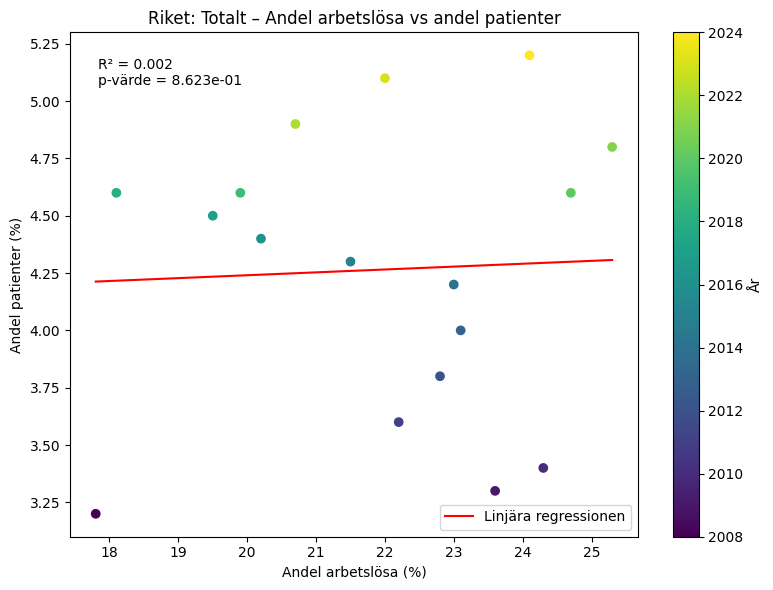

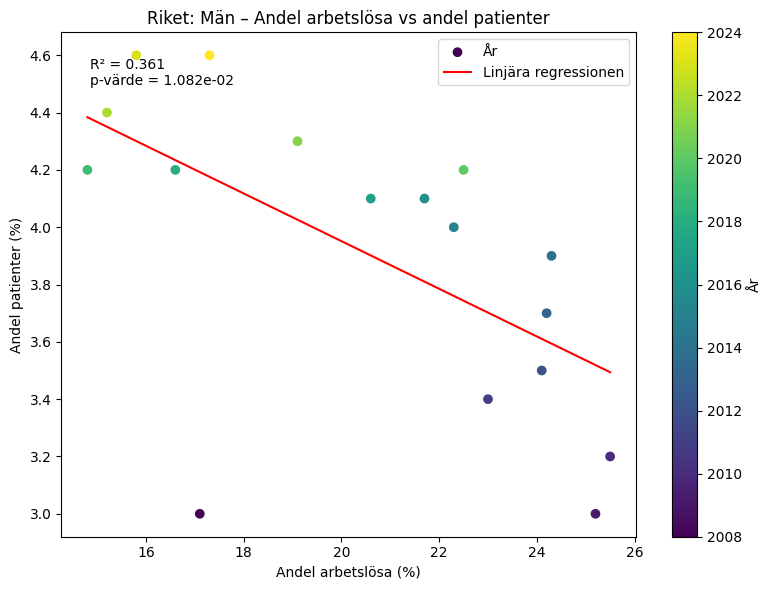

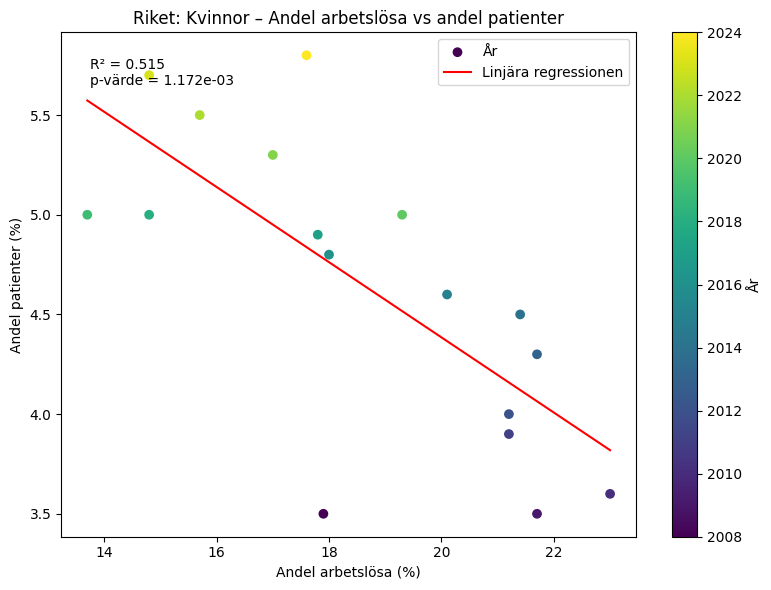

In [64]:
# Filtrera Riket och endast kön totalt
riket_df_totalt = merge_df[(merge_df["region"] == "Riket") & (merge_df["kön"] == "totalt")].copy()

# Definiera x och y
x = riket_df_totalt["andel arbetslösa (%)"]
y = riket_df_totalt["andel patienter(%)"]

# Linjär regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Predikterade värden
x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = intercept + slope * x_vals

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=riket_df_totalt["år"], cmap="viridis")
plt.plot(x_vals, y_vals, color='red', label="Linjära regressionen")

plt.xlabel("Andel arbetslösa (%)")
plt.ylabel("Andel patienter (%)")
plt.title("Riket: Totalt – Andel arbetslösa vs andel patienter")

# Visa R² och p-värde
plt.text(
    0.05, 0.95,
    f"R² = {r_value**2:.3f}\np-värde = {p_value:.3e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.colorbar(label="År")
plt.legend()
plt.tight_layout()
plt.show()

# Lista över kön
kon_list = ["män", "kvinnor"]

for kon in kon_list:
    df_kon = merge_df[(merge_df["region"] == "Riket") & (merge_df["kön"] == kon)].copy()
    
    x = df_kon["andel arbetslösa (%)"]
    y = df_kon["andel patienter(%)"]
    
    # Linjär regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Predikterade värden
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = intercept + slope * x_vals
    
    # Plott
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, c=df_kon["år"], cmap="viridis", label="År")
    plt.plot(x_vals, y_vals, color='red', label="Linjära regressionen")
    
    plt.xlabel("Andel arbetslösa (%)")
    plt.ylabel("Andel patienter (%)")
    plt.title(f"Riket: {kon.capitalize()} – Andel arbetslösa vs andel patienter")
    
    # Visa R² och p-värde
    plt.text(
        0.05, 0.95,
        f"R² = {r_value**2:.3f}\np-värde = {p_value:.3e}",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )
    
    plt.colorbar(label="År")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Tolkning Figur 2 
De tre diagrammen undersöker sambandet mellan andelen arbetslösa och andelen patienter i Sverige under perioden 2008–2024, presenterat för totalbefolkningen samt uppdelat på män och kvinnor. Jämförelsen avslöjar skillnader som är dolda i den aggregerade dataanalysen.

Totalt: R²-värdet på 0.002 indikerar att endast 0,2 % av variationen i andelen patienter kan förklaras av variationen i andelen arbetslösa. Detta är ett mycket lågt värde och inte statistiskt signifikant (p = 0.862), vilket innebär att det praktiskt taget inte finns något linjärt samband mellan de två variablerna.

Män: R²-värdet på 0,361 visar att ungefär 36 % av variationen i mäns patientandel kan förklaras statistiskt av variationen i mäns arbetslöshet. För män finns ett statistiskt signifikant samband (p = 0.011), vilket innebär att det är osannolikt att sambandet uppstått av en slump.

Kvinnor: R²-värdet på 0,515 visar att sambandet är starkast och tydligast för kvinnor. Sambandet är statistiskt signifikant (p = 0.001). Detta innebär att en större del av variationen i andelen patienter kan förklaras av arbetslöshet jämfört med män. Resultatet tyder på att sambandet mellan arbetslöshet och hälsa är något tydligare för kvinnor än för män.

Men vi har endast 16 datapunkter vilket gör att analysen blir känsligare. Dessutom bland patienterna finns åldersgrupperna 15-19 och 65-74 som är studerar eller är pensionärer.


### Figur 3

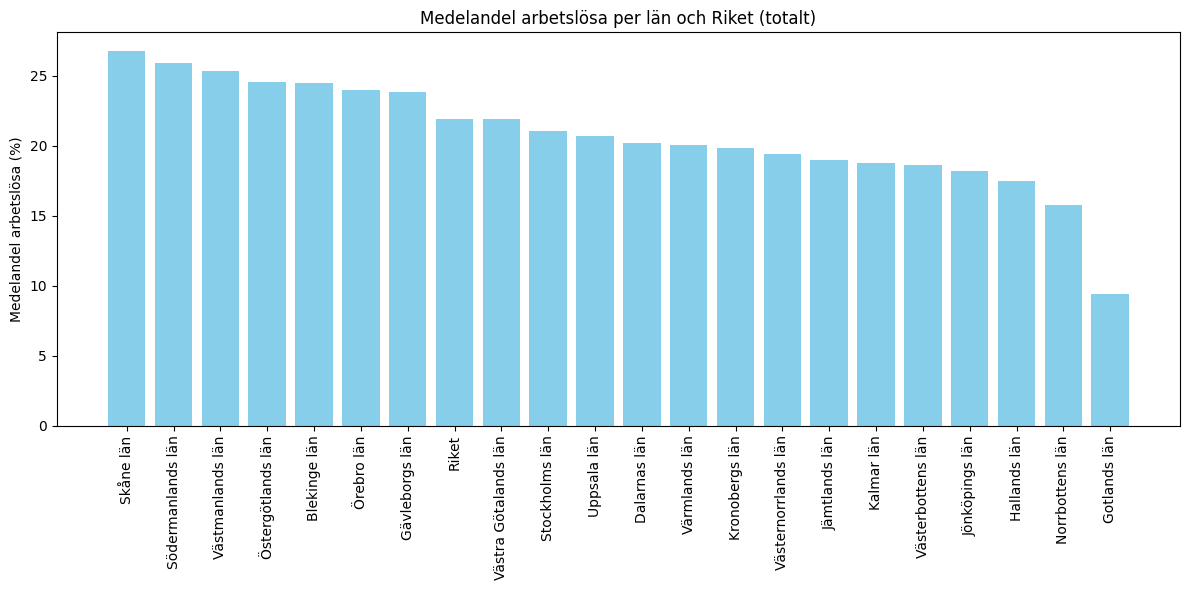

In [65]:
# Filtrera totalt kön
totalt_df = merge_df[merge_df["kön"] == "totalt"].copy()

# Beräkna medelvärde arbetslöshet per region
medel_arb = totalt_df.groupby("region")["andel arbetslösa (%)"].mean().sort_values(ascending=False)

# Skapa stapeldiagram
plt.figure(figsize=(12, 6))
plt.bar(medel_arb.index, medel_arb.values, color="skyblue")
plt.xticks(rotation=90)  # Vertikala regionnamn
plt.ylabel("Medelandel arbetslösa (%)")
plt.title("Medelandel arbetslösa per län och Riket (totalt)")
plt.tight_layout()
plt.show()


### Figur 3 Tolkning 
Vi undersöker vilka län som har högst och lägst andel arbetslöshet. Vi vet från tidigare att Gotlands län och Norrbottens län hade flera saknade värden - 36 respektive 14 - för arbetslöshet. Vi låter bli använda dessa två och undersöker två län med högre arbetslöshet och två med lägre för att undersöka om samband med psykisk ohälsa råder baserad på län

### Figur 4

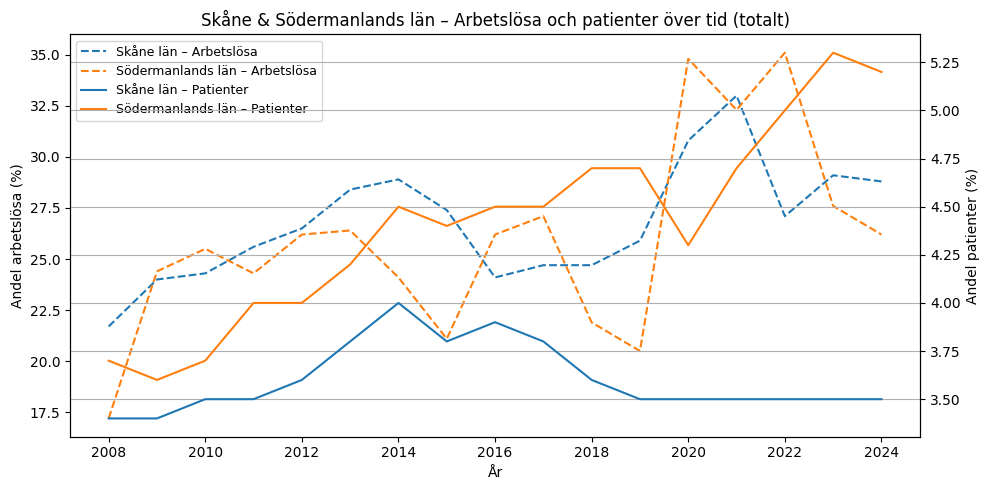

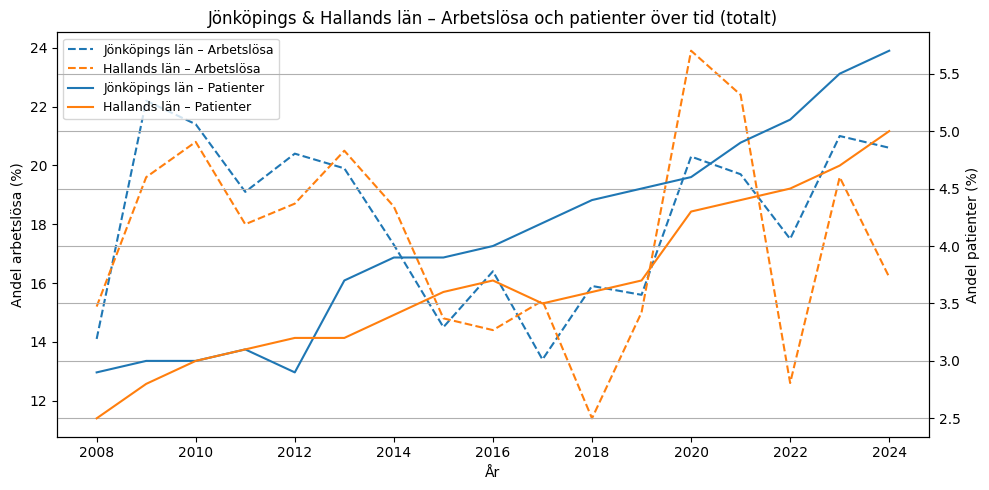

In [66]:
# --- Första gruppen: Skåne & Södermanlands län ---
lan_grupp1 = ["Skåne län", "Södermanlands län"]
totalt_df1 = merge_df[(merge_df["region"].isin(lan_grupp1)) & (merge_df["kön"] == "totalt")]

fig, ax1 = plt.subplots(figsize=(10, 5))

# Arbetslöshet på vänster y-axel
for region in lan_grupp1:
    subset = totalt_df1[totalt_df1["region"] == region]
    ax1.plot(subset["år"], subset["andel arbetslösa (%)"], label=f"{region} – Arbetslösa", linestyle="--")
ax1.set_xlabel("År")
ax1.set_ylabel("Andel arbetslösa (%)")

# Patientandel på höger y-axel
ax2 = ax1.twinx()
for region in lan_grupp1:
    subset = totalt_df1[totalt_df1["region"] == region]
    ax2.plot(subset["år"], subset["andel patienter(%)"], label=f"{region} – Patienter", linestyle="-")
ax2.set_ylabel("Andel patienter (%)")

# Samlad legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=9)

plt.title("Skåne & Södermanlands län – Arbetslösa och patienter över tid (totalt)")
plt.grid(True)
plt.tight_layout()
plt.show()


# --- Andra gruppen: Jönköpings & Hallands län ---
lan_grupp2 = ["Jönköpings län", "Hallands län"]
totalt_df2 = merge_df[(merge_df["region"].isin(lan_grupp2)) & (merge_df["kön"] == "totalt")]

fig, ax1 = plt.subplots(figsize=(10, 5))

for region in lan_grupp2:
    subset = totalt_df2[totalt_df2["region"] == region]
    ax1.plot(subset["år"], subset["andel arbetslösa (%)"], label=f"{region} – Arbetslösa", linestyle="--")
ax1.set_xlabel("År")
ax1.set_ylabel("Andel arbetslösa (%)")

ax2 = ax1.twinx()
for region in lan_grupp2:
    subset = totalt_df2[totalt_df2["region"] == region]
    ax2.plot(subset["år"], subset["andel patienter(%)"], label=f"{region} – Patienter", linestyle="-")
ax2.set_ylabel("Andel patienter (%)")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", fontsize=9)

plt.title("Jönköpings & Hallands län – Arbetslösa och patienter över tid (totalt)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Tolkning Figur 4
Diagram 1: Skåne & Södermanlands län
Arbetslösheten i båda länen följer samma makrotrend med toppar kring 2010 (finanskris) och 2020 (pandemi). Skåne har genomgående högre arbetslöshet än Södermanland.
Patientandelen är också högre i Skåne än i Södermanland under hela perioden. Båda länen visar en svagt stigande långtidstrend samt en tydlig topp under pandemiåren.
Sambandet: I detta par går högre arbetslöshet hand i hand med högre patientandel – Skåne ligger högre på båda variablerna. Men trots ökad arbetslöshet kring under pandemin fortsatte patientandelen att minska och ligga på samma nivå om vi tror på vår dataset. 

Diagram 2: Jönköpings & Hallands län
Arbetslösheten är systematiskt högre i Jönköpings län än i Hallands län, med samma krisrelaterade toppar.
Patientandelen visar däremot ett omvänt mönster: Hallands län har en högre patientandel än Jönköpings län, trots sin lägre arbetslöshet. Båda har en pandemitopp.
Vi ser ingen tydlig samband mellan arbetslöshet och psykisk ohälsa.

### Slutsats 

Projektet visar inte ett tydligt samband mellan arbetslöshet och psykisk ohälsa i Sveriges län under perioden 2008–2024. Projektet stötte dock på flera metodologiska utmaningar. En central begränsning var datakvaliteten och tillgängligheten, särskilt avsaknaden av åldersspecifik data för arbetslöshet i kombination med regional indelning. Detta medförde att åldersgrupper som 15–19 år och 65–74 år inkluderades i analysen, vilket kan ha påverkat resultatens tillförlitlighet eftersom dessa grupper innehåller många studerande respektive pensionärer. Dessutom uppvisade arbetslöshet datasetet saknade värden, särskilt för vissa län och kvartal, vilket hanterades genom ersättning med nollor eller borttagning. Detta kan ha introducerat viss osäkerhet i beräkningarna. Ett spännande framtida studier skulle kunna vara ett mer precist variabelval, där åldersspecifika data för arbetslöshet inkluderas för att öka analysens validitet. Man skulle också kunna undersöka varje sjukdomsdiagnos separat med tanke på att vissa diagnoser kan utlösas på grund av genetiska orsaker eller ålder medan andra har stark koppling till livssituation. 